In [1]:
import pandas as pd
from experiment_utils import run_one_experiment, save_result, run, MLPClassifier, save_result_v1

In [5]:
data = pd.read_csv('../data/Processed_Project_Data/fifa_and_elo_rankings_clean_filled.csv')
data[['home_rank', 'away_rank', 'rank_advantage']]

,home_rank,away_rank,rank_advantage
0,57.0,14.0,-43.0
1,24.0,5.0,-19.0
2,43.0,17.0,-26.0
3,46.0,2.0,-44.0
4,51.0,79.0,28.0
...,...,...,...
1234,35.0,44.0,9.0
1235,11.0,45.0,34.0
1236,18.0,35.0,17.0
1237,35.0,45.0,10.0


In [6]:
X = data[['rank_advantage']]
y = data['result']

label_mapping = {
    -1:0,
    0:1,
    1:2
}

y_enc = y.map(label_mapping)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42, shuffle = False)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype = torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.long)


In [9]:
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

input_dim = X_train_tensor.shape[1]

model = MLPClassifier(input_dim=input_dim)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Epoch 50/1000 | train loss = 0.8231 | val loss = 0.7813 | val acc = 0.6533
Epoch 100/1000 | train loss = 0.8218 | val loss = 0.7835 | val acc = 0.6583
Epoch 150/1000 | train loss = 0.8152 | val loss = 0.7851 | val acc = 0.6583
Epoch 200/1000 | train loss = 0.8104 | val loss = 0.7890 | val acc = 0.6583
Epoch 250/1000 | train loss = 0.8129 | val loss = 0.7935 | val acc = 0.6583
Epoch 300/1000 | train loss = 0.8151 | val loss = 0.7996 | val acc = 0.6583
Epoch 350/1000 | train loss = 0.8140 | val loss = 0.8011 | val acc = 0.6583
Epoch 400/1000 | train loss = 0.8164 | val loss = 0.8056 | val acc = 0.6583
Epoch 450/1000 | train loss = 0.8158 | val loss = 0.8095 | val acc = 0.6583
Epoch 500/1000 | train loss = 0.8169 | val loss = 0.8127 | val acc = 0.6583
Epoch 550/1000 | train loss = 0.8130 | val loss = 0.8164 | val acc = 0.6583
Epoch 600/1000 | train loss = 0.8151 | val loss = 0.8217 | val acc = 0.6583
Epoch 650/1000 | train loss = 0.8074 | val loss = 0.8211 | val acc = 0.6583
Epoch 700/100

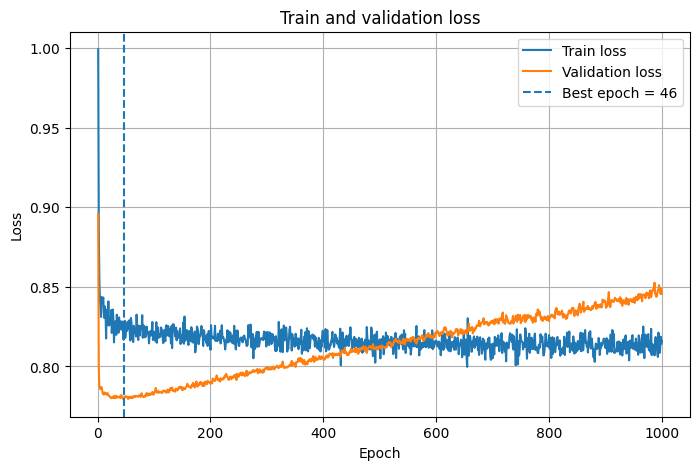

0.5685483870967742

In [10]:
run_one_experiment(model, criterion, optimizer, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor)

In [11]:
best_num_epochs = 46

summary, results_df = run(
    model_class=MLPClassifier,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
    num_epochs=best_num_epochs,
)

Run 1/10
Accuracy: 0.5685 | Precision: 0.3770 | Recall: 0.4958 | Specificity: 0.7549 | F1: 0.4234

Run 2/10
Accuracy: 0.5645 | Precision: 0.3691 | Recall: 0.4928 | Specificity: 0.7550 | F1: 0.4189

Run 3/10
Accuracy: 0.5685 | Precision: 0.3770 | Recall: 0.4958 | Specificity: 0.7549 | F1: 0.4234

Run 4/10
Accuracy: 0.5645 | Precision: 0.3691 | Recall: 0.4928 | Specificity: 0.7550 | F1: 0.4189

Run 5/10
Accuracy: 0.5685 | Precision: 0.3770 | Recall: 0.4958 | Specificity: 0.7549 | F1: 0.4234

Run 6/10
Accuracy: 0.5685 | Precision: 0.3770 | Recall: 0.4958 | Specificity: 0.7549 | F1: 0.4234

Run 7/10
Accuracy: 0.5645 | Precision: 0.3692 | Recall: 0.4949 | Specificity: 0.7557 | F1: 0.4203

Run 8/10
Accuracy: 0.5645 | Precision: 0.3759 | Recall: 0.4886 | Specificity: 0.7512 | F1: 0.4181

Run 9/10
Accuracy: 0.5645 | Precision: 0.3691 | Recall: 0.4928 | Specificity: 0.7550 | F1: 0.4189

Run 10/10
Accuracy: 0.5685 | Precision: 0.3770 | Recall: 0.4958 | Specificity: 0.7549 | F1: 0.4234

Summary o

In [12]:
save_result(
    experiment_name="Experiment_1-3_ranks_diff",
    summary=summary
)

save_result_v1(
    experiment_name="Experiment_1-3_ranks_diff",
    summary=summary
)


Saved result for Experiment_1-3_ranks_diff
File: ../results/experiment_summary_final.csv

Saved result for Experiment_1-3_ranks_diff
File: ../results/experiment_summary_v1.csv
